<a href="https://colab.research.google.com/github/Jaslyn10/Water-Point-Analysis/blob/main/dsmlcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
)

from scipy.stats import chi2 as chi2_dist
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import spearmanr

# Setting random seed for Reproducibility

In [ ]:
RANDOM_STATE = 42

# Load Dataset

In [ ]:
file_path = "/content/drive/MyDrive/dsmlassignment/data/Water_Point_Data_Exchange.csv"
df = pd.read_csv(file_path, low_memory=False)

df.shape, df.head()

((838209, 52),
    row_id           #source   #lat_deg   #lon_deg             #report_date  \
 0  13,710  Water For People  15.140910 -91.011342  2018 May 18 12:00:00 AM   
 1  16,504  Water For People  14.996823 -91.234158  2019 Apr 02 12:00:00 AM   
 2  14,940  Water For People -17.503702 -65.715479  2019 Jun 18 12:00:00 AM   
 3  15,397  Water For People   0.422690  30.728980  2005 Sep 07 12:00:00 AM   
 4  15,418  Water For People -17.432842 -65.723005  2019 Jun 18 12:00:00 AM   
 
   #status_id #water_source                    #water_tech #country_name  \
 0        Yes           NaN                 System Gravity     Guatemala   
 1         No           NaN           Sistema por gravedad     Guatemala   
 2        Yes           NaN  Sistema por bombeo y gravedad       Bolivia   
 3         No           NaN               Protected Spring        Uganda   
 4        Yes           NaN           Sistema por gravedad       Bolivia   
 
                     #adm1  ... count          New 

**Observation**: About 8 lakh rows with 52 features

# EDA And Preprocessing

## Inspect Column Info

In [ ]:
df.columns.tolist()

['row_id',
 '#source',
 '#lat_deg',
 '#lon_deg',
 '#report_date',
 '#status_id',
 '#water_source',
 '#water_tech',
 '#country_name',
 '#adm1',
 '#adm2',
 '#adm3',
 '#install_year',
 '#installer',
 '#rehab_year',
 '#rehabilitator',
 '#management',
 '#pay',
 '#status',
 '#fecal_coliform_value',
 '#fecal_coliform_presence',
 '#subjective_quality',
 '#activity_id',
 '#scheme_id',
 '#notes',
 '#photo_lnk',
 '#orig_lnk',
 '#data_lnk',
 '#country_id',
 'clean_country_id',
 'clean_country_name',
 'clean_adm1',
 'clean_adm2',
 'clean_adm3',
 'clean_adm4',
 'water_source_clean',
 'water_source_category',
 'water_tech_clean',
 'water_tech_category',
 'facility_type',
 'management_clean',
 'status_clean',
 'count',
 'New Georeferenced Column',
 'lat_lon_deg',
 '#converted',
 'public_data_source',
 'created_timestamp',
 'updated',
 '#pay_clean',
 '#subjective_quality_clean',
 'dataset_title']

In [ ]:
drop_cols = [
    "#rehab_year", "#rehabilitator",
    "#fecal_coliform_value", "#fecal_coliform_presence",
    "#installer", "#orig_lnk", "#scheme_id",
    "#subjective_quality", "#subjective_quality_clean",
    "#pay", "#pay_clean",
    "#photo_lnk", "#notes",
    "#status", #Cus target is status id and model may get confused. Hence we delete this to avoid data leakage
    "#converted",
    "New Georeferenced Column",
    "lat_lon_deg",
    "public_data_source",
    "created_timestamp",
    "updated",
    "dataset_title",
    "#activity_id"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [ ]:
keep_cols = [
    "#status_id",
    "#lat_deg",
    "#lon_deg",
    "clean_country_name",
    "clean_adm1",
    "clean_adm2",
    "water_source_clean",
    "water_source_category",
    "water_tech_clean",
    "water_tech_category",
    "facility_type",
    "management_clean",
]

df = df[keep_cols].copy()
df.shape

(838209, 12)

In [ ]:
df.describe(include='all')

,#status_id,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean
count,838209,838209.000000,838209.000000,838209,838192,838182,730499,730499,595861,590206,838209,480126
unique,3,NaN,NaN,84,608,3593,12,8,30,4,4,9
top,Yes,NaN,NaN,Uganda,Western,Cox'S Bazar,Borehole/Tubewell,Well,Hand Pump,Hand Pump,Improved,Community Management
freq,634195,NaN,NaN,142600,143191,68850,323312,600529,148189,332172,699615,226815
mean,NaN,4.959407,18.692655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,10.781465,36.358229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-88.996556,-140.739594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.360433,-2.434839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,6.570526,29.038143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,9.867422,33.611182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['#status_id', '#lat_deg', '#lon_deg', 'clean_country_name',
       'clean_adm1', 'clean_adm2', 'water_source_clean',
       'water_source_category', 'water_tech_clean', 'water_tech_category',
       'facility_type', 'management_clean'],
      dtype='object')

In [ ]:
df.columns.nunique()

12

In [ ]:
for col in df.columns:
  if(df[col].dtype == "object"):
    print(df[col].value_counts())

#status_id
Yes        634195
No         132675
Unknown     71339
Name: count, dtype: int64
clean_country_name
Uganda          142600
Nigeria         119484
Sierra Leone    102778
Bangladesh       70894
Ghana            68250
                 ...  
Iran                 1
China                1
Senegal              1
Georgia              1
Paraguay             1
Name: count, Length: 84, dtype: int64
clean_adm1
Western            143191
Chittagong          68989
Northern            51453
Eastern             50775
Central             34067
                    ...  
East Kazakhstan         1
Tatarstan               1
Duarte                  1
Sughd                   1
Nsanje                  1
Name: count, Length: 608, dtype: int64
clean_adm2
Cox'S Bazar            68850
Western Rural          61301
Wassa East             21537
Greater Monrovia       13969
South 24 Parganas       9622
                       ...  
Badhan                     1
Concepción de Maria        1
Sablale             

In [ ]:
df["#status_id"].value_counts()

,count
#status_id,
Yes,634195
No,132675
Unknown,71339


Observation: Dataset is imbalanced

In [ ]:
df = df[df["#status_id"].isin(["Yes", "No"])].copy()

df["target"] = df["#status_id"].map({
    "Yes": 1,
    "No": 0
})
df.head()

,#status_id,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,Yes,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,NaN,NaN,NaN,NaN,Unknown,NaN,1
1,No,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,NaN,NaN,NaN,NaN,Unknown,NaN,0
2,Yes,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,NaN,NaN,NaN,NaN,Unknown,NaN,1
3,No,0.422690,30.728980,Uganda,Western,Kamwenge,Protected Well,Well,NaN,NaN,Improved,NaN,0
4,Yes,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,NaN,NaN,NaN,NaN,Unknown,NaN,1


In [ ]:
df["target"].value_counts(normalize=True) #this gives proportional counts instead of direct counts

,proportion
target,
1,0.826992
0,0.173008


In [ ]:
df["#status_id"].value_counts()

,count
#status_id,
Yes,634195
No,132675


In [ ]:
df = df.drop(columns=["#status_id"])

### Dataset acquired after keeping only the required columns and defining target values clearly.

This is the raw dataset so far. Following this step missing values and outliers are handled.

The given dataset now has 12 features and 766870 ~ 7 lakh samples.

Also the **dataset is imbalanced as 82% is positive cases and 17% is negative cases.**

In [ ]:
df.to_csv("/content/drive/MyDrive/dsmlassignment/data/initial1data.csv")

In [ ]:
df.shape

(766870, 12)

## Handling Missing values

In [ ]:
print(f"Missing before:\n{df.isnull().sum()}\n")

Missing before:
#lat_deg                      0
#lon_deg                      0
clean_country_name            0
clean_adm1                   17
clean_adm2                   17
water_source_clean        95875
water_source_category     95875
water_tech_clean         197495
water_tech_category      203079
facility_type                 0
management_clean         302136
target                        0
dtype: int64



### Clean_adm1 column missing value Imputation and removing invalid geolocations if exists

In [ ]:
df[df['clean_adm1'].isnull()] #All are from Antarctica, so irrelevant to water point analysis


,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
114294,-88.996556,62.635035,Antarctica,NaN,NaN,Borehole/Tubewell,Well,Hand Pump - Afridev,Hand Pump,Improved,Community Management,1
276284,-82.591521,36.960546,Antarctica,NaN,NaN,Borehole/Tubewell,Well,Hand Pump - Afridev,Hand Pump,Improved,NaN,1
277971,-80.926325,31.242966,Antarctica,NaN,NaN,Rainwater Harvesting,Rainwater Harvesting,NaN,NaN,Improved,Private Operator/Delegated Management,1
278016,-82.631734,42.698157,Antarctica,NaN,NaN,Borehole/Tubewell,Well,Hand Pump - Afridev,Hand Pump,Improved,NaN,1
280738,-80.925184,31.397293,Antarctica,NaN,NaN,Rainwater Harvesting,Rainwater Harvesting,NaN,NaN,Improved,Private Operator/Delegated Management,1
280879,-81.081146,31.411025,Antarctica,NaN,NaN,Undefined Well,Well,NaN,NaN,Unknown,Community Management,1
288841,-81.007860,30.464047,Antarctica,NaN,NaN,Protected Well,Well,NaN,NaN,Improved,Community Management,0
288993,-80.947694,31.356487,Antarctica,NaN,NaN,Rainwater Harvesting,Rainwater Harvesting,NaN,NaN,Improved,Private Operator/Delegated Management,1
290385,-80.767724,29.926402,Antarctica,NaN,NaN,Protected Well,Well,NaN,NaN,Improved,Community Management,1
290551,-80.722982,30.000616,Antarctica,NaN,NaN,Borehole/Tubewell,Well,Hand Pump - Afridev,Hand Pump,Improved,Community Management,0


**Observation**: All the cases here are from Antarctica where we don't need a water point (just boil ice and drink it if you are thirsty)

**Final verdict**: Delete these rows.

In [ ]:
invalid_geo = (
    (df["#lat_deg"].abs() > 90) |
    (df["#lon_deg"].abs() > 180) |
    (df["clean_country_name"] == "Antarctica")
)
n_invalid = invalid_geo.sum()
df = df[~invalid_geo].copy()
print(f"Dropped {n_invalid} rows with invalid/Antarctica geography.")
print(n_invalid)

Dropped 0 rows with invalid/Antarctica geography.
0


### water_source_clean column missing value Imputation

In [ ]:
df[df['water_source_clean'].isnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,NaN,NaN,NaN,NaN,Unknown,NaN,1
1,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,NaN,NaN,NaN,NaN,Unknown,NaN,0
2,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,NaN,NaN,NaN,NaN,Unknown,NaN,1
4,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,NaN,NaN,NaN,NaN,Unknown,NaN,1
6,13.351420,-86.042173,Nicaragua,Jinotega,San Rafael del Norte,NaN,NaN,NaN,NaN,Unknown,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838022,8.337343,-13.059553,Sierra Leone,Western,Western Rural,NaN,NaN,Kiosk,Public Tapstand,Improved,Private Operator/Delegated Management,1
838028,-1.725206,30.044377,Rwanda,Amajyaruguru,Rulindo,NaN,NaN,Public Tapstand,Public Tapstand,Improved,NaN,1
838029,15.230924,-90.994328,Guatemala,Quiché,Sacapulas,NaN,NaN,NaN,NaN,Unknown,NaN,1
838032,13.158045,-86.162575,Nicaragua,Jinotega,La Concordia,NaN,NaN,NaN,NaN,Unknown,NaN,1


**Observation**: Water source type is strongly regional, so hence, a local mode imputation was done

In [ ]:
def mode_impute(df: pd.DataFrame, col: str, group_cols: list, fallback: str = "Unknown") -> pd.Series:
    series = df[col].copy()
    group_modes = (
        df.dropna(subset=[col])
        .groupby(group_cols)[col]
        .agg(lambda x: x.mode().iloc[0])
    )
    mask = series.isnull()
    # Map each null row to its group's mode
    keys = df.loc[mask, group_cols]
    if len(group_cols) == 1:
        keys = keys.iloc[:, 0]
        series.loc[mask] = keys.map(group_modes).fillna(fallback).values
    else:
        idx = pd.MultiIndex.from_frame(keys)
        mapped = group_modes.reindex(idx).values
        series.loc[mask] = pd.Series(mapped, index=df.index[mask]).fillna(fallback)
    return series

Grouped by country and clean_adm1

In [ ]:
df["water_source_clean"] = mode_impute(
    df, "water_source_clean",
    group_cols=["clean_country_name", "clean_adm1"],
    fallback="Unknown"
)
print(f"water_source_clean nulls after imputation: {df['water_source_clean'].isnull().sum()}")

water_source_clean nulls after imputation: 0


### water_source_category column missing value imputation

In [ ]:
df[df['water_source_category'].isnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1
1,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,0
2,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1
4,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1
6,13.351420,-86.042173,Nicaragua,Jinotega,San Rafael del Norte,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838022,8.337343,-13.059553,Sierra Leone,Western,Western Rural,Piped Water,NaN,Kiosk,Public Tapstand,Improved,Private Operator/Delegated Management,1
838028,-1.725206,30.044377,Rwanda,Amajyaruguru,Rulindo,Protected Well,NaN,Public Tapstand,Public Tapstand,Improved,NaN,1
838029,15.230924,-90.994328,Guatemala,Quiché,Sacapulas,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1
838032,13.158045,-86.162575,Nicaragua,Jinotega,La Concordia,Surface Water (River/Stream/Lake/Pond/Dam),NaN,NaN,NaN,Unknown,NaN,1


In [ ]:
df[df['water_source_category'].notnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
3,0.422690,30.728980,Uganda,Western,Kamwenge,Protected Well,Well,NaN,NaN,Improved,NaN,0
5,15.412214,-87.690247,Honduras,Yoro,El Negrito,Borehole/Tubewell,Well,NaN,NaN,Improved,NaN,1
7,15.573651,-87.709757,Honduras,Yoro,El Negrito,Borehole/Tubewell,Well,NaN,NaN,Improved,NaN,1
8,-1.579777,30.091098,Rwanda,Amajyaruguru,Gicumbi,Protected Well,Well,NaN,NaN,Improved,NaN,1
9,-0.016706,30.317999,Uganda,Western,Kitagwenda,Protected Well,Well,NaN,NaN,Improved,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838204,-26.046125,31.208600,Eswatini,Hhohho,Pigg's Peak,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1
838205,-25.759157,31.412132,Eswatini,Hhohho,Timphisini,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1
838206,-26.165489,31.106723,Eswatini,Hhohho,Nkhaba,Protected Well,Well,Public Tapstand,Public Tapstand,Improved,NaN,1
838207,-25.834665,31.487158,Eswatini,Hhohho,Mayiwane,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1


**Observation**: water_source_category is a direct coarsening of water_source_clean, so the missing values were re-driven from the water_source_clean column.

In [ ]:
df["water_source_clean"].value_counts()

,count
water_source_clean,
Borehole/Tubewell,307187
Protected Well,196589
Piped Water,109285
Undefined Well,59002
Surface Water (River/Stream/Lake/Pond/Dam),41133
Rainwater Harvesting,19969
Unprotected Well,16602
Protected Spring,11518
Sand or Sub-surface Dam,3848


In [ ]:
SOURCE_CATEGORY_MAP = {
    "Borehole/Tubewell":                             "Well",
    "Protected Well":                                "Well",
    "Undefined Well":                                "Well",
    "Unprotected Well":                              "Well",
    "Piped Water":                                   "Piped Water",
    "Surface Water (River/Stream/Lake/Pond/Dam)":    "Surface Water",
    "Rainwater Harvesting":                          "Rainwater Harvesting",
    "Protected Spring":                              "Spring",
    "Undefined Spring":                              "Spring",
    "Unprotected Spring":                            "Spring",
    "Sand or Sub-surface Dam":                       "Sand or Sub-surface Dam",
    "Delivered Water":                               "Delivered Water",
    "Packaged Water":                                "Packaged Water",
    "Unknown":                                       "Unknown",
}

df["water_source_category"] = df["water_source_clean"].map(SOURCE_CATEGORY_MAP)

In [ ]:
df["water_source_category"] = df["water_source_category"].fillna("Unknown")
print(f"water_source_category nulls after re-derivation: {df['water_source_category'].isnull().sum()}")

water_source_category nulls after re-derivation: 0


### water_Tech_clean column missing value Imputation

In [ ]:
df[df['water_tech_clean'].isnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,NaN,NaN,Unknown,NaN,1
1,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,NaN,NaN,Unknown,NaN,0
2,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,NaN,NaN,Unknown,NaN,1
3,0.422690,30.728980,Uganda,Western,Kamwenge,Protected Well,Well,NaN,NaN,Improved,NaN,0
4,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,NaN,NaN,Unknown,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838116,13.248631,-86.138302,Nicaragua,Jinotega,San Sebastián de Yalí,Borehole/Tubewell,Well,NaN,NaN,Improved,NaN,1
838162,-1.822145,30.033820,Rwanda,Amajyaruguru,Rulindo,Protected Well,Well,NaN,NaN,Improved,NaN,1
838167,-17.600048,-65.777737,Bolivia,Cochabamba,Arani,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,NaN,NaN,Unknown,NaN,1
838189,0.362469,30.424610,Uganda,Western,Kamwenge,Borehole/Tubewell,Well,NaN,NaN,Improved,NaN,0


**Observation**: Technology choice depends heavily on source type and country-level supply chains, so, replaced missing values by **mode by (country + source_category)**

In [ ]:
df["water_tech_clean"] = mode_impute(
    df, "water_tech_clean",
    group_cols=["clean_country_name", "water_source_category"],
    fallback="Unknown"
)
print(f"water_tech_clean nulls after imputation: {df['water_tech_clean'].isnull().sum()}")

water_tech_clean nulls after imputation: 0


### water_tech_category column missing value Imputation

In [ ]:
df[df['water_tech_category'].isnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump - Electric,NaN,Unknown,NaN,1
1,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump - Electric,NaN,Unknown,NaN,0
2,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump,NaN,Unknown,NaN,1
3,0.422690,30.728980,Uganda,Western,Kamwenge,Protected Well,Well,Hand Pump - Afridev,NaN,Improved,NaN,0
4,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump,NaN,Unknown,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838162,-1.822145,30.033820,Rwanda,Amajyaruguru,Rulindo,Protected Well,Well,Public Tapstand,NaN,Improved,NaN,1
838167,-17.600048,-65.777737,Bolivia,Cochabamba,Arani,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump,NaN,Unknown,NaN,1
838173,-25.794354,31.460127,Eswatini,Hhohho,Timphisini,Borehole/Tubewell,Well,Hand Pump - Rope,NaN,Improved,NaN,1
838189,0.362469,30.424610,Uganda,Western,Kamwenge,Borehole/Tubewell,Well,Hand Pump - Afridev,NaN,Improved,NaN,0


In [ ]:
s= df[df['water_tech_category'].notnull()]
m= s[s['water_tech_clean']== 'Motorised Pump - Electric']
c = ['water_tech_clean','water_tech_category']
m[c]

,water_tech_clean,water_tech_category


In [ ]:
r=df[df['water_tech_category'].isnull()]
r[r['water_tech_clean']== 'Hydram Pump']
#r['target'].value_counts()

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
14181,8.489945,-13.227565,Sierra Leone,Western,Western Urban,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
18033,8.487654,-13.231181,Sierra Leone,Western,Western Urban,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
254243,8.464640,-13.233000,Sierra Leone,Western,Western Urban,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
268149,8.463410,-13.223700,Sierra Leone,Western,Western Urban,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
331621,8.472516,-13.278871,Sierra Leone,Western,Western Urban,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
...,...,...,...,...,...,...,...,...,...,...,...,...
739396,8.307910,-13.189600,Sierra Leone,Western,Western Rural,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
739832,8.380857,-13.258904,Sierra Leone,Western,Western Rural,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
739882,8.376400,-13.239200,Sierra Leone,Western,Western Rural,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Community Management,1
741048,8.379710,-13.238200,Sierra Leone,Western,Western Rural,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Hydram Pump,NaN,No facilities,Private Operator/Delegated Management,1


**Observation**: water_tech_category is a direct coarsening of water_tech_clean, so the missing values were re-driven from the water_tech_clean column.

In [ ]:
df["water_tech_clean"].value_counts()

,count
water_tech_clean,
Hand Pump,163321
Hand Pump - Afridev,141319
Public Tapstand,124790
Hand Pump - India Mark,82312
Kiosk,75799
Motorized Pump,49156
Motorized Pump - Electric,35702
Rope and Bucket,20750
Hand Pump - No. 6,15041


In [ ]:
unique_values_tech = list(df['water_tech_category'].unique())

In [ ]:
unique_values_tech

[nan, 'Hand Pump', 'Public Tapstand', 'Motorized Pump', 'Rope and Bucket']

In [ ]:
TECH_CATEGORY_MAP = {'Motorized Pump - Electric': "Motorized Pump",
 'Motorized Pump': 'Motorized Pump',
 'Hand Pump - Afridev': "Hand Pump",
 'Hand Pump': "Hand Pump",
 'Public Tapstand':  'Public Tapstand',
 'Unknown': "Unknown",
 'Hand Pump - India Mark': "Hand Pump",
 'Hand Pump - Rope': "Hand Pump",
 'Hand Pump - Nira': "Hand Pump",
 'Hand Pump - Kardia': "Hand Pump",
 'Kiosk':  'Public Tapstand',
 'Hand Pump - Consallen': "Hand Pump",
 'Hand Pump - Bush Type': "Hand Pump",
 'Hand Pump - Canzee': "Hand Pump",
 'Hand Pump - Tara': "Hand Pump",
 'Motorized Pump - Solar': "Motorized Pump",
 'Hand Pump - Malda': "Hand Pump",
 'Hand Pump - Temple/Mandir': "Hand Pump",
 'Hand Pump - Vergnet': "Hand Pump",
 'Hydram Pump':  "Kinetic Pump",
 'Hand Pump - Mono': "Hand Pump",
 'Hand Pump - Blue': "Hand Pump",
 'Hand Pump - EMAS': "Hand Pump",
 'Rope and Bucket': 'Rope and Bucket',
 'Motorized Pump - Diesel': "Motorized Pump",
 'Hand Pump - Walimi': "Hand Pump",
 'Hand Pump - Indus': "Hand Pump",
 'Hand Pump - SWN 80': "Hand Pump",
 'Hand Pump - Climax': "Hand Pump",
 'Hand Pump - PB Mark II': "Hand Pump",
 'Hand Pump - No. 6': "Hand Pump"
}

In [ ]:
df["water_tech_category"] = df["water_tech_clean"].map(TECH_CATEGORY_MAP)
print(f"water_tech_category nulls after imputation: {df['water_tech_category'].isnull().sum()}")

water_tech_category nulls after imputation: 0


### management_clean column missing value Imputation

In [ ]:
df[df['management_clean'].isnull()]

,#lat_deg,#lon_deg,clean_country_name,clean_adm1,clean_adm2,water_source_clean,water_source_category,water_tech_clean,water_tech_category,facility_type,management_clean,target
0,15.140910,-91.011342,Guatemala,Quiché,San Pedro Jocopilas,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump - Electric,Motorized Pump,Unknown,NaN,1
1,14.996823,-91.234158,Guatemala,Quiché,San Antonio Ilotenango,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump - Electric,Motorized Pump,Unknown,NaN,0
2,-17.503702,-65.715479,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump,Motorized Pump,Unknown,NaN,1
3,0.422690,30.728980,Uganda,Western,Kamwenge,Protected Well,Well,Hand Pump - Afridev,Hand Pump,Improved,NaN,0
4,-17.432842,-65.723005,Bolivia,Cochabamba,Tiraque,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Motorized Pump,Motorized Pump,Unknown,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
838204,-26.046125,31.208600,Eswatini,Hhohho,Pigg's Peak,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1
838205,-25.759157,31.412132,Eswatini,Hhohho,Timphisini,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1
838206,-26.165489,31.106723,Eswatini,Hhohho,Nkhaba,Protected Well,Well,Public Tapstand,Public Tapstand,Improved,NaN,1
838207,-25.834665,31.487158,Eswatini,Hhohho,Mayiwane,Surface Water (River/Stream/Lake/Pond/Dam),Surface Water,Public Tapstand,Public Tapstand,No facilities,NaN,1


**Observation**: Highest missing rate (39.4%).

Strategy:
* Group by country: use country-level mode where possible.
* Countries where 100% is missing → "Unknown" (cannot infer).

In [ ]:
df["management_clean"] = mode_impute(
    df, "management_clean",
    group_cols=["clean_country_name"],
    fallback="Unknown"
)
print(f"management_clean nulls after imputation: {df['management_clean'].isnull().sum()}")

management_clean nulls after imputation: 0


## Finding and Handling Additional Missing values

Like empty spaces, "unknown", "null", "Null", "-", "N/A" string values etc.

In [ ]:
PSEUDO_NULL_EXACT = {
    "clean_adm2": ["unknown 2", "unknown 4", "unknown 7"], #"unknown 2/4/7" in Kenya
    "facility_type": ["Unknown"],
}

for col, bad_values in PSEUDO_NULL_EXACT.items():
    before = df[col].isnull().sum()
    df[col] = df[col].replace(bad_values, np.nan)
    after = df[col].isnull().sum()
    print(f"[pseudo-null] {col}: {after - before} values converted to NaN")

[pseudo-null] clean_adm2: 0 values converted to NaN
[pseudo-null] facility_type: 0 values converted to NaN


In [ ]:
GLOBAL_PSEUDO_NULLS = ["", " ", "NULL", "Null", "null", "NaN", "nan", "N/A",
                       "n/a", "NA", "None", "none", "-", "--", "?",
                       "undefined", "Undefined", "unspecified", "Unspecified",
                       "not specified", "not available", "Not Available"]

cat_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) == "str"]
for col in cat_cols:
    mask = df[col].isin(GLOBAL_PSEUDO_NULLS)
    if mask.any():
        df.loc[mask, col] = np.nan
        print(f"[global sweep] {col}: {mask.sum()} additional values → NaN")

print(f"\nMissing after pseudo-null standardisation:\n{df.isnull().sum()}\n")


Missing after pseudo-null standardisation:
#lat_deg                     0
#lon_deg                     0
clean_country_name           0
clean_adm1                   0
clean_adm2                  11
water_source_clean           0
water_source_category        0
water_tech_clean             0
water_tech_category          0
facility_type            82381
management_clean             0
target                       0
dtype: int64



Columns clean_adm2 and facility type now have missing values that need to be handled.

### Handling missing values of column: clean_adm2

In [ ]:
df["clean_adm2"] = mode_impute(
    df, "clean_adm2",
    group_cols=["clean_country_name", "clean_adm1"],
    fallback="Unknown"
)
print(f"clean_adm2 nulls after imputation: {df['clean_adm2'].isnull().sum()}")

clean_adm2 nulls after imputation: 0


### Handling missing values of column: facility type

Using mode imputation.
Facility type correlates with water source category and country context.

In [ ]:
df["facility_type"] = mode_impute(
    df, "facility_type",
    group_cols=["clean_country_name", "water_source_category"],
    fallback="Improved"   # global dataset mode is "Improved"
)
print(f"facility_type nulls after imputation: {df['facility_type'].isnull().sum()}")

facility_type nulls after imputation: 0


### Final Missing Value Report

In [ ]:
missing_final = df.isnull().sum()
print(missing_final)
print(f"\nFinal shape: {df.shape}")
print(f"Rows removed: {766870 - len(df):,}") #initial size - final size
print(f"\nTarget distribution:\n{df['target'].value_counts(normalize=True).round(4)}")

print(f"\nValue counts for imputed columns:")
for col in ["water_source_clean", "water_source_category", "water_tech_category",
            "facility_type", "management_clean"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

#lat_deg                 0
#lon_deg                 0
clean_country_name       0
clean_adm1               0
clean_adm2               0
water_source_clean       0
water_source_category    0
water_tech_clean         0
water_tech_category      0
facility_type            0
management_clean         0
target                   0
dtype: int64

Final shape: (766853, 12)
Rows removed: 17

Target distribution:
target
1    0.827
0    0.173
Name: proportion, dtype: float64

Value counts for imputed columns:

water_source_clean:
water_source_clean
Borehole/Tubewell                             307187
Protected Well                                196589
Piped Water                                   109285
Undefined Well                                 59002
Surface Water (River/Stream/Lake/Pond/Dam)     41133
Rainwater Harvesting                           19969
Unprotected Well                               16602
Protected Spring                               11518
Sand or Sub-surface Dam             

## Outliers

In [ ]:
df.describe()

,#lat_deg,#lon_deg,target
count,766853.000000,766853.000000,766853.000000
mean,4.966365,19.639384,0.826990
std,10.933464,37.176773,0.378256
min,-34.463900,-140.739594,0.000000
25%,0.281255,-2.391713,1.000000
50%,6.436918,29.796909,1.000000
75%,10.326594,34.006338,1.000000
max,68.345000,169.504188,1.000000


### Checking for invalid outlier coordinates

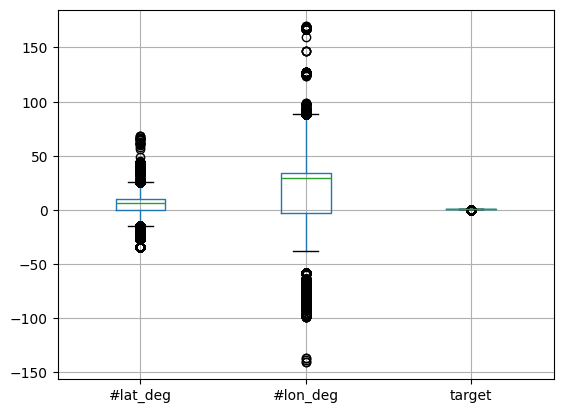

In [ ]:
df.boxplot()
plt.show()

 **Insight**: Around 8–14% of lat/lon are "outliers" but these are real coordinates from Guatemala, Bolivia, Bangladesh, Pacific Islands etc. The dataset is global. Clipping would silently delete valid data. Hence, these values are left as it is.

## Re-checking missing data and saving the final cleaned data

In [ ]:
print(f"Dataset after preprocessing")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True).round(3)}")
# Renaming columns for simplicity
RENAME_MAP = {
    "#lat_deg":              "lat",
    "#lon_deg":              "lon",
    "clean_country_name":    "country",
    "clean_adm1":            "adm1",
    "clean_adm2":            "adm2",
    "water_source_clean":    "water_source",
    "water_source_category": "water_source_cat",
    "water_tech_clean":      "water_tech",
    "water_tech_category":   "water_tech_cat",
    "facility_type":         "facility",
    "management_clean":      "management",
    "target":                "target",
}

df = df.rename(columns=RENAME_MAP)
print(f"\nColumns renamed: {df.columns.tolist()}")
df.to_csv("/content/drive/MyDrive/dsmlassignment/data/initial1data_cleaned.csv", index=False)
print("\nSaved --> initial1data_cleaned.csv")

Dataset after preprocessing
#lat_deg                 0
#lon_deg                 0
clean_country_name       0
clean_adm1               0
clean_adm2               0
water_source_clean       0
water_source_category    0
water_tech_clean         0
water_tech_category      0
facility_type            0
management_clean         0
target                   0
dtype: int64

Final shape: (766853, 12)
Target distribution:
target
1    0.827
0    0.173
Name: proportion, dtype: float64

Columns renamed: ['lat', 'lon', 'country', 'adm1', 'adm2', 'water_source', 'water_source_cat', 'water_tech', 'water_tech_cat', 'facility', 'management', 'target']

Saved --> initial1data_cleaned.csv


## Handling Dataset Size

In [ ]:
df= pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/initial1data_cleaned.csv")

In [ ]:
df["target"].value_counts()

,count
target,
1,634180
0,132673


**Strategy to reduce dataset size:** Draw 50K from class 1 and 50K from class 0 to handle *Class Imbalance*.

Each target class is stratified by country, so no single country dominates the dataset.

**Expected Target dataset now has a 50-50 target split with 100K samples in total**

In [ ]:
SAMPLE_PER_CLASS = 50000
def stratified_class_sample(df, target_col, class_label, n, strat_col, random_state=42):
    subset = df[df[target_col] == class_label].copy()
    counts = subset[strat_col].value_counts()
    total = len(subset)
    alloc = (counts / total * n).round().astype(int)

    # fixing allocation to get exactly n samples (n=50K here)
    diff = n - alloc.sum()
    if diff != 0:
        idx = alloc.nlargest(abs(diff)).index
        alloc[idx] += int(np.sign(diff))

    # Ensure we do not samples that the number of rows for that country that actually exist
    alloc = alloc.clip(upper=counts)

    parts = []
    for stratum, k in alloc.items():  #for country , country proportional count
        stratum_rows = subset[subset[strat_col] == stratum]
        take = min(k, len(stratum_rows)) #further ensures that we don't try to retrieve than the total rows of that country
        if take > 0:
            parts.append(stratum_rows.sample(n=take, random_state=random_state))

    return pd.concat(parts)


sample_pos = stratified_class_sample(df, "target", 1, SAMPLE_PER_CLASS, "country", RANDOM_STATE)
sample_neg = stratified_class_sample(df, "target", 0, SAMPLE_PER_CLASS, "country", RANDOM_STATE)

df_sample = (
    pd.concat([sample_pos, sample_neg])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Reduced dataset shape: {df_sample.shape}")
print(f"Class balance after sampling:\n{df_sample['target'].value_counts()}")
print(f"Countries represented: {df_sample['country'].nunique()} / {df['country'].nunique()}")
print(f"adm1 represented:{df_sample['adm1'].nunique()} / {df['adm1'].nunique()}")
print(f"adm2 represented:{df_sample['adm2'].nunique()} / {df['adm2'].nunique()}\n")

Reduced dataset shape: (100000, 12)
Class balance after sampling:
target
0    50000
1    50000
Name: count, dtype: int64
Countries represented: 64 / 80
adm1 represented:437 / 562
adm2 represented:2593 / 3406



**Result**: Reduced Dataset of 100K samples with 50K samples per target class.

In [ ]:
df_enc = df_sample.drop(columns=["water_source_cat", "water_tech_cat"]).copy()
print(f"Dropped redundant columns: {["water_source_cat", "water_tech_cat"]}")

Dropped redundant columns: ['water_source_cat', 'water_tech_cat']


In [ ]:
df_enc.shape

(100000, 10)

Saved the reduced dataset file to csv **reduced_data**

In [ ]:
df_enc.to_csv("/content/drive/MyDrive/dsmlassignment/data/reduced_data.csv", index = False)

**Observation**: Since water_source_cat and water_tech_cat columns are derived from columns water_source and water_tech respectively, which is basically just the simplified version of these columns, these 2 columns were considered redundant and deleted.

So now, there resultant dataset contains 100K samples and 9 features plus 1 target feature with equal(50K) samples per class.


Resultant dataset is stored in variable **df_enc**

## Data Preprocessing: Encoding

In [ ]:
#Load the reduced dataset
df = pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/reduced_data.csv")
df.shape

(100000, 10)

### EDA for the categorical columns

In [ ]:
cat_cols = ["water_source", "water_tech", "management", "facility", "country"]
for col in cat_cols:
    stats = (df.groupby(col)["target"].agg(count="count", target_rate="mean").sort_values("target_rate")) #sorted from worst to best
    #grouped each category and then took the mean of its corresponding target to check what % of target case is positive for that category.
    spread = stats["target_rate"].max() - stats["target_rate"].min()
    #to check whether the feature is informative by checking how different the categories are based max-min difference of prob.(means)

    print(f"\n{col}:{df[col].nunique()} unique values and spread = {spread:.3f}")
    print(stats.round(4).to_string())


water_source:13 unique values and spread = 0.648
                                            count  target_rate
water_source                                                  
Protected Spring                             1923       0.3521
Sand or Sub-surface Dam                       599       0.3623
Borehole/Tubewell                           44868       0.4157
Protected Well                              25570       0.5061
Surface Water (River/Stream/Lake/Pond/Dam)   5276       0.5112
Undefined Well                               7501       0.5158
Rainwater Harvesting                         2561       0.5248
Unprotected Well                             1794       0.6377
Delivered Water                                33       0.6667
Undefined Spring                              137       0.6861
Piped Water                                  9736       0.8568
Packaged Water                                  1       1.0000
Unknown                                         1       1.0000

wate

**Observations**
* water_source: Has 13 unique values and about ~65% spread where mean values per category range from ~ 0.35 to 1.
* water_tech: Has 31 unique values and 100% spread meaning very strong separation between categories.
* management: 10 unique values and 0.474 ~ 50% spread meaning enough separation between categories.
* facility: 3 unique values but only ~7.8% spread meaning very poor separation between categories implying it is a weak predictor and hence we drop this feature.
* country has 64 unique values i.e it has very high cardinality

**Conclusion**
* water_source, water_tech, management undergo Ordinal encoding
* country, adm1 and adm2 are all location features with high cardinality so they undergo target encoding
* lat and long features are already numeric and are location coordinates and hence can not be messed with.
* we drop feature facility as it is a weak predictor for the target class.

### Encoding the categorical columns

In [ ]:
df = df.drop(columns=["facility"]).copy()
df.shape

(100000, 9)

In [ ]:
# separate the data and target
X = df.drop(columns=["target"])
y = df["target"]

#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Smooth Target Encoding

Smoothing (k=10) prevents small-count categories (e.g. a country with 2 rows) from getting extreme encoded values like 0.0 or 1.0, which would be noise rather than signal.

global_mean was computed from y_train only. This value serves as the fallback value for any category seen in test but not in train like rare adm1 or adm2 values.

In [ ]:
global_mean = float(y_train.mean())

def target_encode_fit(X_col, y, global_mean, k=10):
    df_tmp = pd.DataFrame({"cat": X_col.values, "target": y.values})
    stats = df_tmp.groupby("cat")["target"].agg(["count", "mean"])
    smoothed = (stats["count"] * stats["mean"] + k * global_mean) / (stats["count"] + k) #Smooth target encoding formula
    return smoothed  # dictionary with index = category, values = encoded float


def target_encode_transform(X_col, encoding_map, global_mean):
    return X_col.map(encoding_map).fillna(global_mean) #mapping the values found by target_encode_fit function to the cateogories per column here

Fit maps on training data and use and apply same mapping for both train and test sets to avoid **Data Leakage**

In [ ]:
te_maps = {}
for col in ["country", "adm1", "adm2"]:
    te_maps[col] = target_encode_fit(X_train[col], y_train, global_mean)

    new_col = col + "_te"
    X_train[new_col] = target_encode_transform(X_train[col], te_maps[col], global_mean)
    X_test[new_col] = target_encode_transform(X_test[col], te_maps[col], global_mean)
    X_train = X_train.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])

In [ ]:
print(f"Unseen In-test fallbacks:{X_test[new_col].isna().sum()}")

Unseen In-test fallbacks:0


#### Ordinal Encoding

The rank for each category per column was determined by the mean(target) in train set alone as using the whole dataset would leak test set target information into the rank computation.

Unseen categories get a median value as fallback value.

In [ ]:
def ordinal_encode_fit(X_col, y):
    means = y.groupby(X_col).mean()  # avg target per category
    ordered = means.sort_values().index  # sort from low to high
    return {cat: i for i, cat in enumerate(ordered)}


def ordinal_encode_transform(X_col, mapping, fallback=-1):
    return X_col.map(mapping).fillna(fallback).astype(int) #mapping the values


In [ ]:
ord_maps = {}
for col, new_col in [("water_source", "water_source_ord"),
                     ("water_tech",   "water_tech_ord"),
                     ("management",   "management_ord")]:
    ord_maps[col] = ordinal_encode_fit(X_train[col], y_train)
    fallback_rank = len(ord_maps[col]) // 2   # median rank for unseen categories

    X_train[new_col] = ordinal_encode_transform(X_train[col], ord_maps[col], fallback_rank)
    X_test[new_col] = ordinal_encode_transform(X_test[col], ord_maps[col], fallback_rank)

    X_train = X_train.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])

#### Final check after encoding

In [ ]:
print(X_train.columns)
print(f"\nX_train shape:{X_train.shape} and X_test: {X_test.shape}")
print("\n",X_train.head())
print("\n Target values:\n", y_train[:5])
print(f"\nMissing values in X_train: {X_train.isnull().sum().sum()} and in X_test: {X_test.isnull().sum().sum()}")
print(f"\nX_train stats:")
print(X_train.describe().round(3).to_string())
print(f"\nX_test stats:")
print(X_test.describe().round(3).to_string())

Index(['lat', 'lon', 'country_te', 'adm1_te', 'adm2_te', 'water_source_ord',
       'water_tech_ord', 'management_ord'],
      dtype='object')

X_train shape:(80000, 8) and X_test: (20000, 8)

              lat        lon  country_te   adm1_te   adm2_te  water_source_ord  \
9812    7.781922 -11.428240    0.666407  0.476132  0.468293                10   
93124   7.647626  -1.778713    0.709133  0.287805  0.206897                 2   
32008  21.208844  92.147122    0.442826  0.440322  0.440371                 2   
11409  -9.986040  30.799550    0.745007  0.436184  0.500000                 2   
33164   0.688171  30.407606    0.490069  0.692308  0.458904                 5   

       water_tech_ord  management_ord  
9812               14               4  
93124              19               4  
32008              15               4  
11409              21               9  
33164              19               4  

 Target values:
 9812     0
93124    0
32008    0
11409    1
33164    0
Name: 

## EDA On Final Dataset

Correlation and Association analysis between all final encoded features and the target

In [ ]:
train_eda = X_train.copy()
train_eda["target"] = y_train.values

### Spearman correlation with target

In [ ]:
spearman_vs_target = {}
for col in X_train.columns:
    r, p = spearmanr(train_eda[col], train_eda["target"])
    spearman_vs_target[col] = {"rho": round(r, 4), "p_value": round(p, 6)}

spearman_df = pd.DataFrame(spearman_vs_target).T.sort_values("rho", key=abs, ascending=False)
print("\nSpearman Correlation with Target:\n")
print(spearman_df.to_string())


Spearman Correlation with Target:

                     rho   p_value
adm2_te           0.5182  0.000000
adm1_te           0.4108  0.000000
country_te        0.3390  0.000000
water_tech_ord    0.2804  0.000000
management_ord    0.2414  0.000000
water_source_ord  0.2130  0.000000
lon              -0.0528  0.000000
lat               0.0063  0.073249


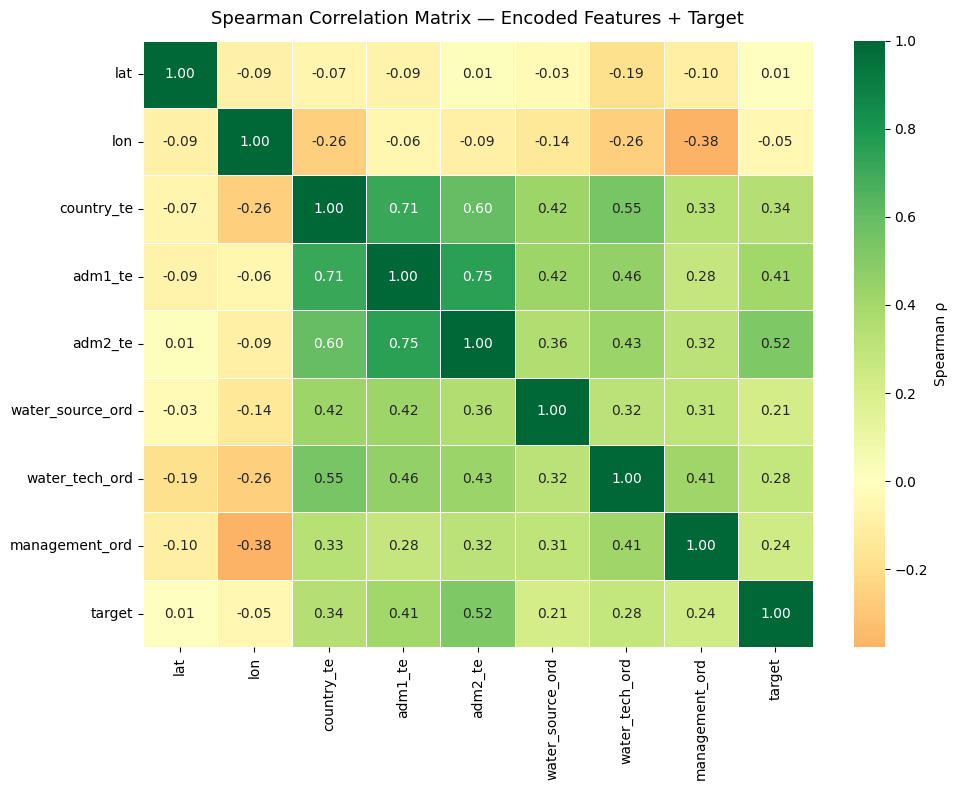

In [ ]:
corr_matrix = train_eda.drop(columns=["lat", "lon"]).copy()  # lat/lon are not ordinal
all_cols = X_train.columns.tolist() + ["target"]
spearman_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for c1 in all_cols:
    for c2 in all_cols:
        r, _ = spearmanr(train_eda[c1], train_eda[c2])
        spearman_matrix.loc[c1, c2] = round(r, 3)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_matrix.astype(float),
    annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.4, ax=ax,
    cbar_kws={"label": "Spearman ρ"}
)
ax.set_title("Spearman Correlation Matrix — Encoded Features + Target", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/spearman_corr_heatmap.png", dpi=150)
plt.show()

**Observation**:
* **Strongest predictors**: adm2, adm1, and country show highest correlation meaning location-based factors are most important.
* **Moderate predictors**: water_tech, management, and water_source useful but weaker signals.
* **Weak predictors**: lat and lon almost have no correlation with target.
* **Solution for lon/lat features**: clustering using KMeans into groups with similar locations and then check if the correlation improves.

### Kmeans on lon/lat features

The k-value was tuned by evaluating target rate separation, cluster size and correlation with the target.

While higher k values increased separation, excessively small clusters indicated potential overfitting.

Therefore, k was selected to balance strong predictive signal with sufficient cluster support.

**Tested k values**
* k = 20 : good fit but presence of small clusters
* k = 15: Spread reduced to ~ 0.4 from ~0.5.
* k = 18: spread reduced but similar to k = 19.

Smaller clusters lead to unstable estimates. While k=20 gave a very good spread but the clusters were highly fragmented which can be noticed in the plot.

At the end k = 18 was selected as it gave an approx. good balance between a good spread and cluster stability.


In [ ]:
scaler_geo = StandardScaler()
coords_train = scaler_geo.fit_transform(X_train[["lat", "lon"]])
coords_test  = scaler_geo.transform(X_test[["lat", "lon"]])

kmeans_geo = KMeans(n_clusters=18, random_state=RANDOM_STATE, n_init=10)
kmeans_geo.fit(coords_train)

KMeans(n_clusters=18, n_init=10, random_state=42)

In [ ]:
X_train["geo_cluster"] = kmeans_geo.labels_
X_test["geo_cluster"]  = kmeans_geo.predict(coords_test)

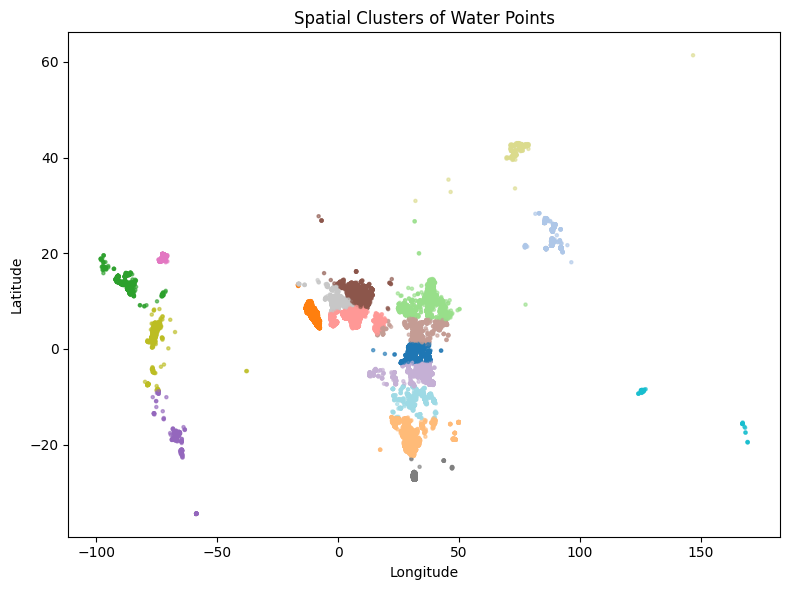

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train["lon"],
    X_train["lat"],
    c=X_train["geo_cluster"],
    cmap="tab20",
    s=5,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Clusters of Water Points")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/kmeans_geocluster_result_k18.png", dpi=150)
plt.show()

In [ ]:
cluster_stats = (
    pd.DataFrame({"geo_cluster": X_train["geo_cluster"], "target": y_train.values})
    .groupby("geo_cluster")["target"]
    .agg(count="count", target_rate="mean")
    .sort_values("target_rate")
)
spread = cluster_stats["target_rate"].max() - cluster_stats["target_rate"].min()
print(f"\nGeo-cluster target rate spread: {spread:.3f}")
print(cluster_stats.round(3).sort_values("geo_cluster"))


Geo-cluster target rate spread: 0.555
             count  target_rate
geo_cluster                    
0            14918        0.544
1             8894        0.500
2            11781        0.637
3             3095        0.554
4             1021        0.752
5             3442        0.576
6            10168        0.341
7              349        0.785
8             3259        0.230
9             6728        0.332
10            6477        0.454
11            1647        0.512
12            2414        0.530
13            3580        0.630
14             468        0.722
15             174        0.460
16              48        0.562
17            1537        0.634


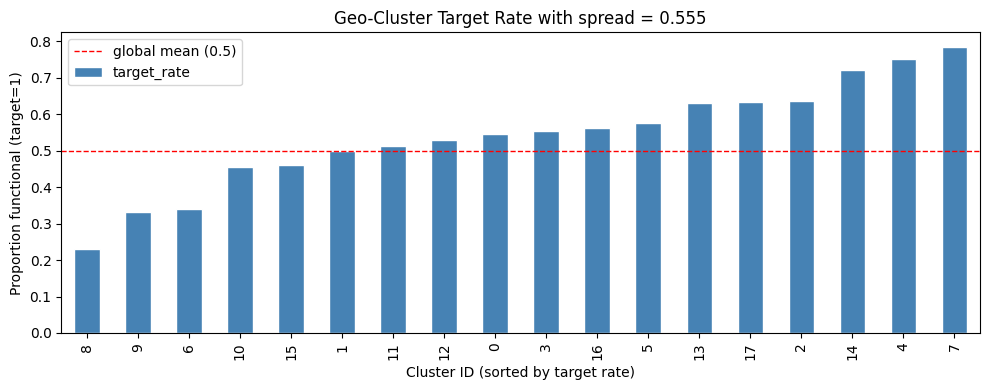

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
cluster_stats["target_rate"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="global mean (0.5)")
ax.set_title(f"Geo-Cluster Target Rate with spread = {spread:.3f}", fontsize=12)
ax.set_xlabel("Cluster ID (sorted by target rate)")
ax.set_ylabel("Proportion functional (target=1)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/geoclusters_target_rate.png", dpi=150)
plt.show()

### Target Encode geo-cluster feature

This feature was formed by applying Kmeans with k=20 on the lon and lat features representing lattitude and longitude of the exact location of water point.

Since it shows a better monotonic relation with target we moved forward with this feature and encoded similarly using smooth target encoding.

In [ ]:
te_maps["geo_cluster"] = target_encode_fit(X_train["geo_cluster"].astype(str), y_train, global_mean)
X_train["geo_cluster_te"] = target_encode_transform(X_train["geo_cluster"].astype(str), te_maps["geo_cluster"], global_mean)
X_test["geo_cluster_te"] = target_encode_transform(X_test["geo_cluster"].astype(str),  te_maps["geo_cluster"], global_mean)

X_train = X_train.drop(columns=["geo_cluster"])
X_test  = X_test.drop(columns=["geo_cluster"])

In [ ]:
r_geo, p_geo = spearmanr(X_train["geo_cluster_te"], y_train)
r_lat, _ = spearmanr(X_train["lat"], y_train)
r_lon, _ = spearmanr(X_train["lon"], y_train)
print(f"\nSpearman rho \nlat vs target:{r_lat:.4f}")
print(f"lon vs target:{r_lon:.4f}")
print(f"geo_cluster_te vs target:{r_geo:.4f}")


Spearman rho 
lat vs target:0.0063
lon vs target:-0.0528
geo_cluster_te vs target:0.2350


In [ ]:
print(f"\nFinal X_train shape:{X_train.shape}")
print(f"Final features:{X_train.columns.tolist()}")


Final X_train shape:(80000, 9)
Final features:['lat', 'lon', 'country_te', 'adm1_te', 'adm2_te', 'water_source_ord', 'water_tech_ord', 'management_ord', 'geo_cluster_te']


In [ ]:
X_train.to_csv("/content/drive/MyDrive/dsmlassignment/data/X_train.csv", index = False)
X_test.to_csv("/content/drive/MyDrive/dsmlassignment/data/X_test.csv", index = False)
y_train.to_csv("/content/drive/MyDrive/dsmlassignment/data/y_train.csv", index = False)
y_test.to_csv("/content/drive/MyDrive/dsmlassignment/data/y_test.csv", index = False)

# Training

In [ ]:
#Load Preprocessed dataset here itself if just want to run from training section

X_train = pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/X_train.csv")
X_test  = pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/X_test.csv")
y_train = pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/y_train.csv").iloc[:, 0]
y_test  = pd.read_csv("/content/drive/MyDrive/dsmlassignment/data/y_test.csv").iloc[:, 0]

In [ ]:
print(X_train.head())
print(y_train.head())

         lat        lon  country_te   adm1_te   adm2_te  water_source_ord  \
0   7.781922 -11.428240    0.666407  0.476132  0.468293                10   
1   7.647626  -1.778713    0.709133  0.287805  0.206897                 2   
2  21.208844  92.147122    0.442826  0.440322  0.440371                 2   
3  -9.986040  30.799550    0.745007  0.436184  0.500000                 2   
4   0.688171  30.407606    0.490069  0.692308  0.458904                 5   

   water_tech_ord  management_ord  geo_cluster_te  
0              14               4        0.636926  
1              19               4        0.340931  
2              15               4        0.500112  
3              21               9        0.633484  
4              19               4        0.544413  
0    0
1    0
2    0
3    1
4    0
Name: target, dtype: int64


Drop lat/lon features as they have weak correlation with the target feature(rho = 0.0063 and rho = -0.0528 respectively). The information they carry is already covered by features like country_te, adm1_te, adm2_te and geo_cluster_te(formed by the lat/lon features using Kmeans clustering).

Retaining these features would simply introduce redundancy without any new predictive information.

In [ ]:
X_train = X_train.drop(columns=["lat", "lon"])
X_test  = X_test.drop(columns=["lat", "lon"])

Now my dataset is ready for training

## Training method Used

Stratified K-Fold Cross-Validation (k=5) with OOF (Out-of-Fold) score collection

**Why?**
Because other methods like GridSearchCV would be computationally expensive and time consuming.

Nested CV was a tempting approach as it handles both validation and tuning but it is more computationally expensive and time consuming that GridSearchCV.

Hence, given the data was already divided into train and test sets with 80 - 20 ratio, Stratified K-fold was used for training.

**Result**
Training data would now be divided into 5 folds
* 5 x 16K validation sets
* 5 x (4 x 16K) training sets in total
* 4 x 16K training set per fold
* 16K validation set per fold

For each fold model will be trained again from start to avoid any **data leakage**.

### Function to split the training dataset

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def cross_val_auc(model, X, y, cv):
    fold_aucs = [] #for plotting auc curves later on
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, proba)
        fold_aucs.append(auc)
        print(f"  Fold {fold+1}: AUC = {auc:.4f}")
    return np.array(fold_aucs)

### Function to evaluate the model performance on Test Set

* Model is trained
* Predictions were made using test set
* Plotted ROC for thresholds and AUC to evaluate model performance \
AUC  >> .5 indicates good model performance

In [ ]:
def evaluate_on_test(model, X_tr, y_tr, X_te, y_te, model_name, ax_roc):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred  = model.predict(X_te)

    auc = roc_auc_score(y_te, proba)
    fpr, tpr, _ = roc_curve(y_te, proba)

    print(f"\n{model_name} - Test Set Results")
    print(f"\nAUC-ROC: {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, pred, digits=4))

    ax_roc.plot(fpr, tpr, label=f"{model_name}  (AUC={auc:.3f})")
    return auc, proba

## Baseline Model

LogisticRegression model

Reason for selecting this model was because of its simplicity, commoness, interpretability, quick computations and provides a baseline model to compare and try improved models.

Applied StandardScalar preprocessing before training model for transforming features such that their mean is zero and standard deviation is one. This is necessary for Logistic Regression since the steps of the solver are dependent on feature scale, causing slow convergence otherwise.

The parameters chosen were:

* C: 1(default value) as strong regularisation would underfit and weaker would overfit. Since it is baseline the value was left as default.
* max_iter: Increased from sklearn default (100) since 200–400 iterations are required for convergence for 7-variable scaled data, 1000 is a safe upper bound.
* solver: Used "lbfgs" as it supports native L2 regularization and is a recommended sklearn default.
* random_state: (RANDOM_STATE = 42) for reproducibility


**No. of runs:** 5-fold stratified CV (5 independent model fits on 64K rows each) and testing on 80K training records is 1 more run.

In [ ]:
lr_pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("clf",LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE))
])

print("Cross-validation (Stratified 5-Fold):")
lr_fold_aucs = cross_val_auc(lr_pipe, X_train, y_train, skf)
print(f"\n  Mean CV AUC: {lr_fold_aucs.mean():.4f} ± {lr_fold_aucs.std():.4f}")

Cross-validation (Stratified 5-Fold):
  Fold 1: AUC = 0.8040
  Fold 2: AUC = 0.8035
  Fold 3: AUC = 0.7983
  Fold 4: AUC = 0.7978
  Fold 5: AUC = 0.8053

  Mean CV AUC: 0.8018 ± 0.0031


**Observation**: The Logistic Regression gives an average 5-fold CV AUC of around **0.80** with very low variance, showing consistent but poor performance. Its linear decision boundary is unable to capture the complex relationships between geographical encoded features and infrastructure type.

## Second Model
Random Forest Model - RandomForestClassification

Reason for selecting this model was:
* It is a **non-linear ensemble algorithm** that can capture complex relationships between geographic target-encoded and ordinal infrastructure variables that are impossible for Logistic Regression to learn
* It does not need **Standard Scaling due to robustness to different feature scales**, unlike Logistic Regression
* It provides **feature importances**, which are useful for understanding why certain predictors matter more than others
* It is a good way of handling **ordinal encoded variables** by making decision tree-like splits based on thresholds

The parameters used:
* n_estimators: 300 trees sufficient for stable OOB error on 80K samples while additional improvement from beyond 300-500 is not worth the increase in complexity.

* max_depth: 20 for maximum depth of the tree to prevent overfitting.
* min_samples_leaf: 20 to prevent oversplitting on rare instances/combination.
* max_features: "sqrt" for reduce ensemble variance.
* class_weight: "balanced" to see if explicit weighting changes performance. Removed later in final model.
* random_state: (RANDOM_STATE = 42) for reproducibility for tree structure and bootstrap sampling.
* n_jobs:-1 to use all available cpus for tree construction.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Cross-validation (Stratified 5-Fold):")
rf_fold_aucs = cross_val_auc(rf_model, X_train, y_train, skf)
print(f"\n  Mean CV AUC: {rf_fold_aucs.mean():.4f} ± {rf_fold_aucs.std():.4f}")

Cross-validation (Stratified 5-Fold):
  Fold 1: AUC = 0.8295
  Fold 2: AUC = 0.8288
  Fold 3: AUC = 0.8267
  Fold 4: AUC = 0.8246
  Fold 5: AUC = 0.8325

  Mean CV AUC: 0.8284 ± 0.0027


**Observation**: Random Forest achieves a meaningfully higher mean 5-fold CV AUC than Logistic Regression (0.82 vs 0.80), confirming that non-linear interactions between features carry real signal that the linear baseline misses.This holds true for all five folds with little variation (σ ≈ 0.003), suggesting robust generalization without dependence on the data split.

## Model Comparison

Comparing RandomForestClassifier with the Baseline model: LogisticRegression

This will answer if the performance difference between these two models statistically significant or not.

**Using McNemar's test**

The common way to compare two classifiers over one test set used in machine learning papers is the **McNemar test**

**Reference**: Dietterich, T.G. (1998). Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms. *Neural Computation*, 10(7), 1895–1923.

**It utilizes all the 20,000 instances of the test set** i.e unlike the Wilcoxon test, McNemar does not operate on the 5 AUC values from the folds, but rather considers the classification performance over the entire 20,000 row dataset, hence providing very high statistical power.

**How it works**: First, we create a 2×2 contingency table of disagreements between classifiers:
- **b01**: those cases in which Model A was correct while Model B was wrong  
- **b10**: those cases in which Model B was correct and Model A was wrong  

The test statistic takes the form: χ² = (|b01 − b10| − 1)² / (b01 + b10) and has the Yates continuity correction which is compared to the χ² distribution with 1 degree of freedom.

All that counts here are the disagreements (b01 and b10)

In [ ]:
def mcnemar_test(model_a, model_b, X_tr, y_tr, X_te, y_te, name_a, name_b):
    # Fit both models on full training set
    model_a.fit(X_tr, y_tr)
    model_b.fit(X_tr, y_tr)

    pred_a = model_a.predict(X_te)
    pred_b = model_b.predict(X_te)
    y_true = y_te.values

    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    # Contingency table
    b11 = int(np.sum( correct_a &  correct_b))  # both correct
    b00 = int(np.sum(~correct_a & ~correct_b))  # both wrong
    b01 = int(np.sum( correct_a & ~correct_b))  # only A correct
    b10 = int(np.sum(~correct_a &  correct_b))  # only B correct

    print(f"McNemar's Test: {name_a} vs {name_b}")
    print(f"  Both correct : {b11}")
    print(f"  Both wrong   : {b00}")
    print(f"  Only {name_a} correct: {b01}")
    print(f"  Only {name_b} correct: {b10}")

    n_disagree = b01 + b10
    if n_disagree == 0:
        print("  No disagreements — models make identical predictions")
        return None

    # McNemar chi-squared with continuity correction (Yates)
    chi2_stat = (abs(b01 - b10) - 1) ** 2 / n_disagree
    p_val = 1 - chi2_dist.cdf(chi2_stat, df=1)

    #printing significant or not based on p value
    sig = "SIGNIFICANT (p < 0.05)" if p_val < 0.05 else "not significant (p >= 0.05)"
    winner = name_a if b01 > b10 else name_b
    print(f"  chi2 = {chi2_stat:.4f},  p = {p_val:.6f}  [{sig}]")
    if p_val < 0.05:
        print(f"  -> {winner} is significantly better on test set")
    print()
    return p_val

In [ ]:
# RF vs LR
p_rf_lr = mcnemar_test(
    rf_model, lr_pipe,
    X_train, y_train, X_test, y_test,
    "Random Forest", "Logistic Regression"
)

McNemar's Test: Random Forest vs Logistic Regression
  Both correct : 13569
  Both wrong   : 4707
  Only Random Forest correct: 1055
  Only Logistic Regression correct: 669
  chi2 = 85.9774,  p = 0.000000  [SIGNIFICANT (p < 0.05)]
  -> Random Forest is significantly better on test set



## Hyperparameter tuning for Randomforest Classifier

**Method Used**: RandomisedSearchCV

**Reason**: Full GridSearchCV would take longer computational time(more than 2 hrs). While RandomisedSearchCV samples 15 random combinations from the parameter grid by setting n_iter = 15, and it took approximately 1hr to run the search.

* n_estimators: [300,500,700] max value capped at 700 due to lower return after 500 for 80K samples.

* max_depth: [10,20,None] None for upper extreme of unbounded depth, while 10 for greater depth as regulariser

* min_samples_leaf: [5, 10, 20] smaller number means tighter splits, while 20 is a more stricter choice

* max_features:['sqrt', 0.5] 0.5 considers half of total features at each split instead of sqrt(n)


**Total possible combinations**: 54

**Combinations used for training**: 15 (randomly sampled, with `random_state=42` to make results reproducible)

**Score criteria used**: AUC-ROC, since the test data set is evenly balanced at 50/50 and AUC can be used regardless of a specific cutoff value


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 0.5],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,           # test 15 random combinations instead of all 36
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

{'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20}
0.8319592


## Final model: RandomForestClassifier

**After hypertuning RandomForest classifier the parameters used were:**
* n_estimators : Increased from 300 to 500 as more trees reduce variance with no overfitting costs
* max_depth: remained as 20
* min_samples_leaf: decreased from 20 to 5 to learn more precise boundaries and avoid too smoother boundaries(underfitting).
* class_weight: removed "balanced" and set to default as the dataset is already balanced. Using balanced would re-assign new weights which may affect overall accuracy.

In [ ]:
rf_model_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Cross-validation (Stratified 5-Fold):")
final_rf_fold_aucs = cross_val_auc(rf_model, X_train, y_train, skf)
print(f"\n  Mean CV AUC: {rf_fold_aucs.mean():.4f} ± {rf_fold_aucs.std():.4f}")

Cross-validation (Stratified 5-Fold):
  Fold 1: AUC = 0.8317
  Fold 2: AUC = 0.8323
  Fold 3: AUC = 0.8311
  Fold 4: AUC = 0.8277
  Fold 5: AUC = 0.8357

  Mean CV AUC: 0.8317 ± 0.0026


**Observation – Random Forest (Final Model)**

Through RandomizedSearchCV, the optimal parameters discovered were:
* n_estimators=500
* max_depth=20
* min_samples_leaf=5
* max_features='sqrt'

Changes made compared to the original RF and its impact:
- By increasing `n_estimators` from 300 to 500, there was a slight reduction in the variance of the ensembles (CV AUC std reduced from 0.0031 and 0.0027 to 0.0026).
- Decreasing `min_samples_leaf` from 20 to 5 made finer leaf splits that helped in distinguishing the geographic clusters well enough, leading to improvement in the AUC.
- It was not necessary to include `class_weight='balanced'` because the data was already 50/50 balanced, and the weighting was distorting the decision boundary unnecessarily.

This optimized model has the highest mean 5-fold CV AUC of all models tested (~0.832) and is chosen as the final model.

## Final Model Comparison

In [ ]:
# RF vs LR
p_rf_final_lr = mcnemar_test(
    rf_model_final, lr_pipe,
    X_train, y_train, X_test, y_test,
    "Random Forest", "Logistic Regression"
)

McNemar's Test: Random Forest vs Logistic Regression
  Both correct : 13412
  Both wrong   : 4442
  Only Random Forest correct: 1320
  Only Logistic Regression correct: 826
  chi2 = 113.2568,  p = 0.000000  [SIGNIFICANT (p < 0.05)]
  -> Random Forest is significantly better on test set



In [ ]:
# RF Tuned vs RF Initial
p_rf_final_rf = mcnemar_test(
    rf_model_final, rf_model,
    X_train, y_train, X_test, y_test,
    "Random Forest (Tuned)", "Random Forest (Initial)"
)

McNemar's Test: Random Forest (Tuned) vs Random Forest (Initial)
  Both correct : 14326
  Both wrong   : 4970
  Only Random Forest (Tuned) correct: 406
  Only Random Forest (Initial) correct: 298
  chi2 = 16.2628,  p = 0.000055  [SIGNIFICANT (p < 0.05)]
  -> Random Forest (Tuned) is significantly better on test set



**Observation — Final Model Comparison**

The McNemar test results confirm:
- **RF Tuned vs Logistic Regression**: Highly significant (p < 0.05). The tuned Random Forest makes significantly fewer errors on the test set than the linear baseline, confirming that non-linear feature interactions are genuinely predictive.
- **RF Tuned vs RF Initial**: Significant (p < 0.05).

These results validate the choice of the tuned Random Forest as the final model.

# Testing



In [ ]:
model_entries = [("Logistic Regression (Baseline)", lr_pipe, lr_fold_aucs),
    ("Random Forest (Initial)", rf_model, rf_fold_aucs),
    ("Random Forest (Tuned/Final)", rf_model_final, final_rf_fold_aucs),]

In [ ]:
rows = []
for name, model, cv_aucs in model_entries:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model":name,
        "CV AUC mean":round(cv_aucs.mean(), 4),
        "CV AUC std":round(cv_aucs.std(), 4),
        "CV AUC min":round(cv_aucs.min(), 4),
        "CV AUC max":round(cv_aucs.max(), 4),
        "Test AUC":round(roc_auc_score(y_test, proba), 4),
        "Test Accuracy":round(accuracy_score(y_test, pred), 4),
        "Precision (1)":round(precision_score(y_test, pred), 4),
        "Recall (1)":round(recall_score(y_test, pred), 4),
        "F1 (1)":round(f1_score(y_test, pred), 4),
    })

## Metrics Summary

In [ ]:
summary_df = pd.DataFrame(rows).set_index("Model")
print(summary_df.to_string())

                                CV AUC mean  CV AUC std  CV AUC min  CV AUC max  Test AUC  Test Accuracy  Precision (1)  Recall (1)  F1 (1)
Model                                                                                                                                      
Logistic Regression (Baseline)       0.8018      0.0031      0.7978      0.8053    0.7856         0.7119         0.7547      0.6278  0.6854
Random Forest (Initial)              0.8284      0.0027      0.8246      0.8325    0.8191         0.7312         0.7924      0.6266  0.6998
Random Forest (Tuned/Final)          0.8317      0.0026      0.8277      0.8357    0.8243         0.7366         0.7962      0.6360  0.7071


**Metrics summary interpretation**

For all models and all folds, the standard deviation of CV AUC is approximately equal to 0.003, suggesting very consistent generalization ability.

The tuned RF model gives better results than any other model on all four metrics (CV AUC, test AUC, accuracy, and F1) simultaneously, thus, confirming as the best model. The difference in AUC between the tuned RF and baseline RF is relatively small (~0.003), yet significant according to McNemar's test.

## ROC Curves

The ROC (Receiver Operating Characteristic) plot shows TPR(sensitivity) against FPR(1-specificity) for each possible classification threshold. The value that summarizes the ROC plot is called the **Area Under the Curve (AUC)** which ranges from 0.5 to 1.0 where 0.5 indicates random classification and 1.0 means perfect classification.

Showing the curves for all three classifiers on the same plot enables easy comparison at any threshold.

KeyboardInterrupt: 

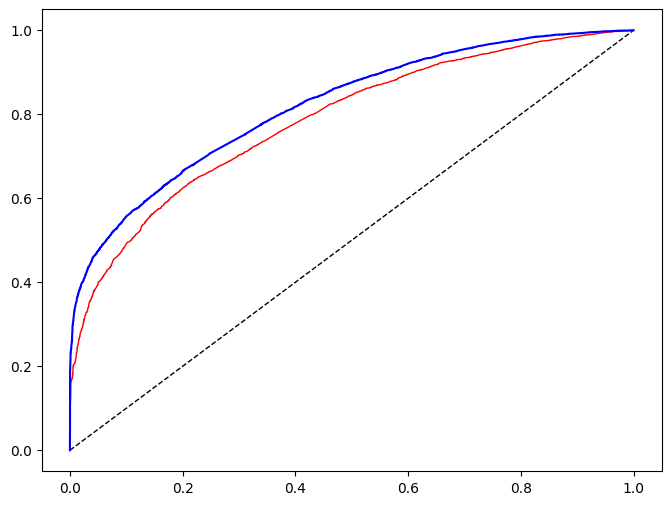

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1.0, label="Random classifier (AUC = 0.500)")

plot_configs = [("Logistic Regression (Baseline)", lr_pipe, "red", 1.0),
    ("Random Forest (Initial)", rf_model, "blue", 1.5),
    ("Random Forest (Tuned/Final)", rf_model_final, "green", 2.5),
]

for name, model, color, lw in plot_configs:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})",color=color, linewidth=lw)

ax.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
ax.set_title("ROC Curves — All Models (Test Set, n = 20,000)", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/roc_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves_all_models.png")

**Observation**

All three curves sit well above the diagonal random baseline.

The fine-tuned Random Forest model represented by the green, thick curve  dominates the other two models, having a larger TPR at any given FPR value.

The difference between the Logistic Regression and the non-linear models is largest in the middle range of FPR (0.1–0.5), where non-linear models can leverage feature interactions while a logistic regression model cannot. On the other hand, the difference between the first and the fine-tuned RF model is smaller, corresponding to the improvement in the numerical AUC by 0.003.



## Confusion Matrices

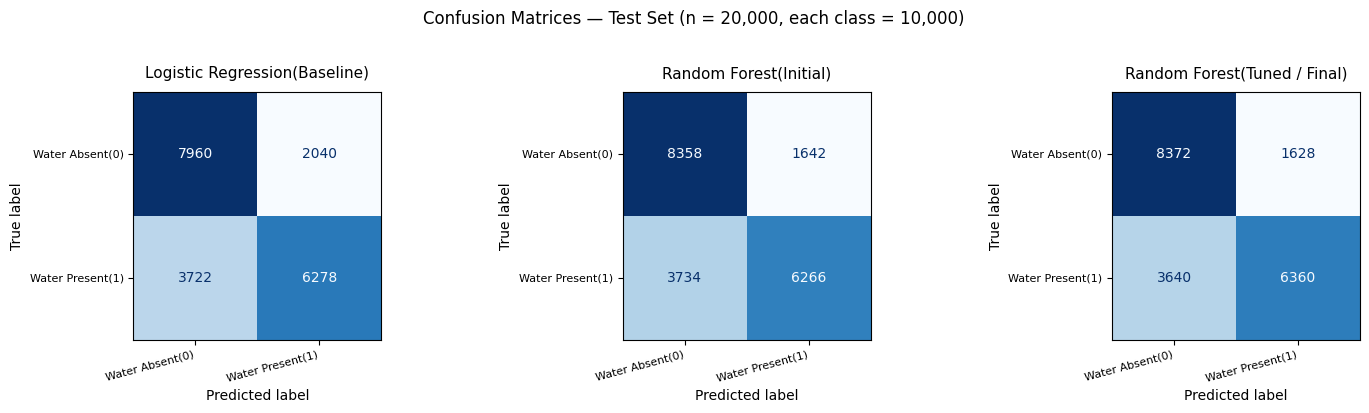

Saved: confusion_matrices_all_models.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_configs = [("Logistic Regression(Baseline)", lr_pipe, axes[0]),
    ("Random Forest(Initial)", rf_model, axes[1]),
    ("Random Forest(Tuned / Final)", rf_model_final, axes[2]),
]

for name, model, ax in cm_configs:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Water Absent(0)", "Water Present(1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11, pad=10)
    # Rotate x-axis labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.suptitle("Confusion Matrices — Test Set (n = 20,000, each class = 10,000)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/confusion_matrices_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_all_models.png")

**Observation**

All three classifiers confuse **water absent as present (False Positives)**.

This stems from the fact that 68% of the signal in the model is driven by geographic target-encoding, that is determined by the proportion of water present points in the particular region and when such regions have more water points present, then the classifier defaults into predicting that label for the minority cases.

Differences between classifiers:
* The **Logistic Regression** model demonstrates the largest number of False Positives (misclassification of the water points absent as present), which corresponds to its lower AUC value.

* Both **Random Forest** models demonstrate a lower number of false positives compared to the Logistic regression classifier


## Classification Reports

The goal here would be to reduce False positives where model predicts water is present while it is actually absent. Hence, **Precision** is monitored to improve model as it measures accuracy of positive predictions.

In [ ]:
for name, model, _, __ in plot_configs:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"Model: {name}")
    print(f"Test AUC: {auc:.4f}")
    print(classification_report(y_test, pred,digits=4,target_names=["Water Absent(0)", "Water Present(1)"]))

Model: Logistic Regression (Baseline)
Test AUC: 0.7856
                  precision    recall  f1-score   support

 Water Absent(0)     0.6814    0.7960    0.7342     10000
Water Present(1)     0.7547    0.6278    0.6854     10000

        accuracy                         0.7119     20000
       macro avg     0.7181    0.7119    0.7098     20000
    weighted avg     0.7181    0.7119    0.7098     20000

Model: Random Forest (Initial)
Test AUC: 0.8191
                  precision    recall  f1-score   support

 Water Absent(0)     0.6912    0.8358    0.7567     10000
Water Present(1)     0.7924    0.6266    0.6998     10000

        accuracy                         0.7312     20000
       macro avg     0.7418    0.7312    0.7282     20000
    weighted avg     0.7418    0.7312    0.7282     20000

Model: Random Forest (Tuned/Final)
Test AUC: 0.8243
                  precision    recall  f1-score   support

 Water Absent(0)     0.6970    0.8372    0.7607     10000
Water Present(1)     0.796

**Observations**

**Precision vs Recall trade-off**: All models show higher recall for class 0 (water absent) than class 1 (water present). This means models identifying water absent points better than water present points. In practical terms, this matters for:
- **Field engineers**: a high recall for class 0 means fewer broken pumps are missed and left unrepaired
- **Resource allocation**: a high precision for class 1 reduces wasted inspection trips to water points the model wrongly flags as needing attention

**Future Scope**: The `#report_date`, `clean_adm3`/`clean_adm4` and `#source` columns from the original dataset are the most promising additions if preprocessing is repeated from the raw data to improve model performance possibly beyond ~85%,

## Feature Importance – Final Model (Tuned Random Forest)

Feature importances based on the Random Forest algorithm indicate how much the node impurity decreases on average across all trees when that particular feature is used for splitting. The higher the importance, the more frequently that feature is selected to differentiate between functional and non-functional water points.

This step was done to understand *why* there is a certain upper limit to the model's performance.

In [ ]:
rf_model_final.fit(X_train, y_train)
fi = pd.Series(rf_model_final.feature_importances_,index=X_train.columns).sort_values(ascending=True)

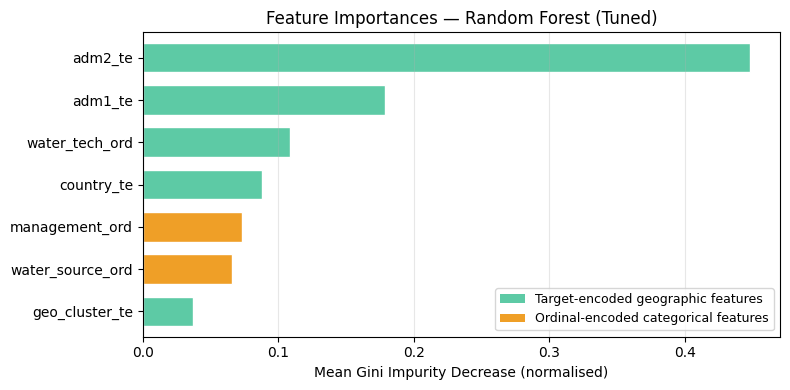

Saved: feature_importances_final_model.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ["#5DCAA5" if "_te" in c else "#EF9F27" for c in fi.index]
fi.plot(kind="barh", ax=ax, color=colors_fi, edgecolor="white", width=0.7)

# Legend
legend_elements = [
    Patch(facecolor="#5DCAA5", label="Target-encoded geographic features"),
    Patch(facecolor="#EF9F27", label="Ordinal-encoded categorical features"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_title("Feature Importances — Random Forest (Tuned)", fontsize=12)
ax.set_xlabel("Mean Gini Impurity Decrease (normalised)", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/dsmlassignment/data/feature_importances_final_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importances_final_model.png")

**Observations and Conclusion**

Geographic target-encoded features (green): ~**68% of total importance**
* `adm2_te` (~45%) – Sub-district level is the strongest predictor among all features. Availability/functionality of water points is highly concentrated by districts based on infrastructure investments, maintenance capabilities, and geological conditions.

* `adm1_te` (~18%) – Provinces provide additional information in prediction the target.

* `country_te` (approx. 9%) and `geo_cluster_te` (approx. 4%) provide additional spatial information at the national and sub-national levels respectively.

Infrastructure features (orange): ~**28% of total importance**
* `water_tech_ord` (~10%) – Technology (Hand Pump vs Motorised Pump vs Kiosk) is the strongest non-geographic feature, aligning with the 100pp target rate spread found in the EDA section
* `management_ord` (approx. 7%) and `water_source_ord` (approx. 7%) are relevant yet weaker predictors

The high importance of geographic features is the cause of the upper bound of performance. The model learns to predict “how many water points in this district are operational(meaning water available)?” and refines its predictions using the type of infrastructure. The lack of temporal features (year of installation, year of last maintenance) and population demands prevents any further improvement.